<a href="https://colab.research.google.com/github/abinaya-2006-abi/sample/blob/main/DAILYHABITS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATA COLLECTION

In [1]:
from google.colab import files
uploaded = files.upload()


Saving archive (1).zip to archive (1).zip


In [2]:
import os
os.listdir()


['.config', 'archive (1).zip', 'sample_data']

In [3]:
import zipfile

zip_path = "archive (1).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset_folder")

print("Unzipped successfully!")


Unzipped successfully!


In [4]:
import os
os.listdir("dataset_folder")


['Daily_Habit_Tracker.csv']

In [5]:
import pandas as pd

df = pd.read_csv("dataset_folder/Daily_Habit_Tracker.csv")

df.head()


,User_ID,Date,Wake_Up_Time,Sleep_Hours,Steps,Calories_Burned,Water_Intake_ml,Study_Hours,Mood_Score
0,U001,2025-09-17,07:02,5.8,19772,2645,571,0.4,2
1,U002,2025-07-15,05:27,5.0,14764,3325,4890,4.1,6
2,U003,2025-05-02,08:32,5.7,2225,1954,3183,4.6,1
3,U004,2025-10-25,06:42,9.4,4055,2144,2530,3.3,4
4,U005,2025-02-02,05:54,5.3,4314,2729,4028,2.5,8


EDA


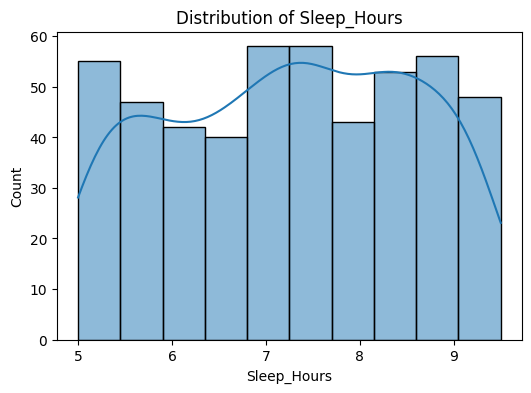

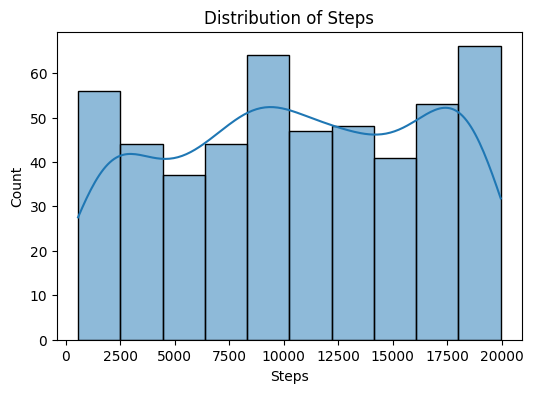

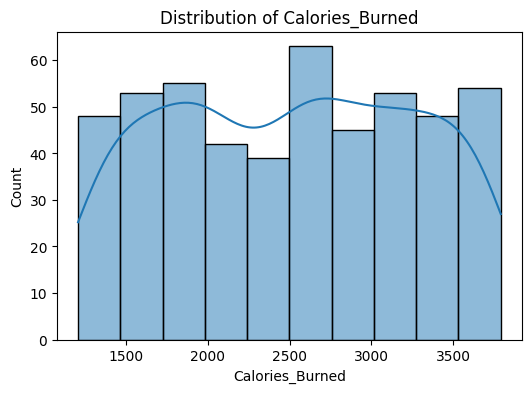

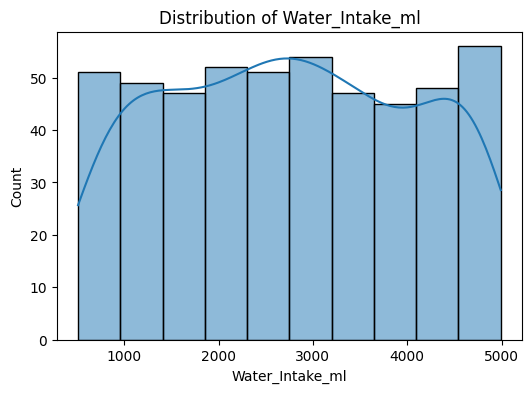

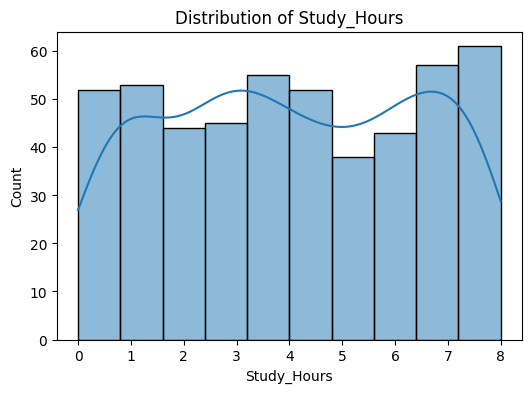

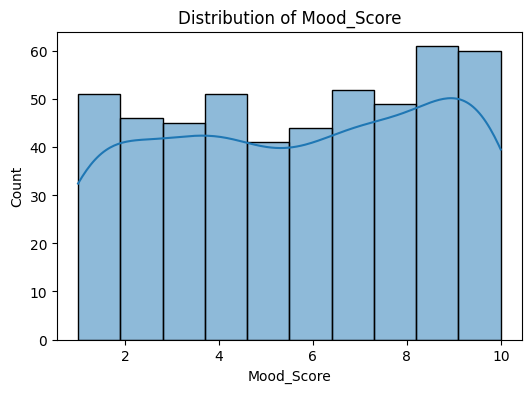

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


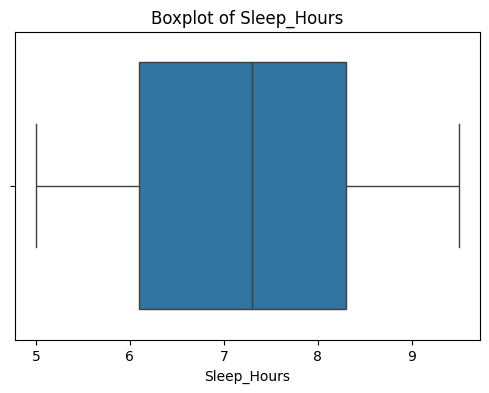

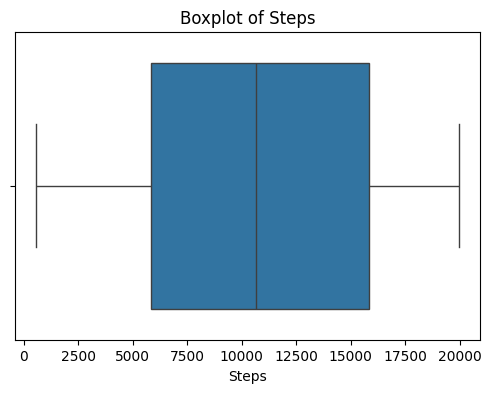

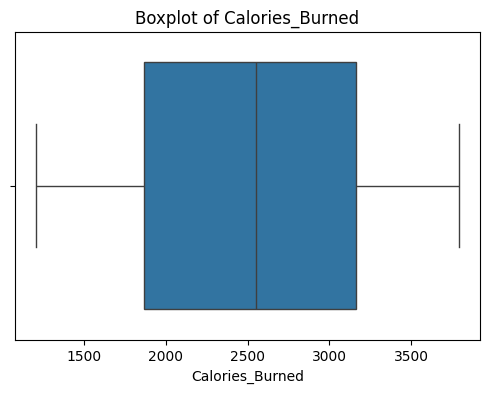

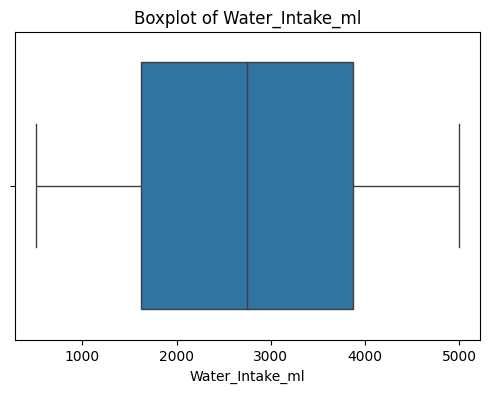

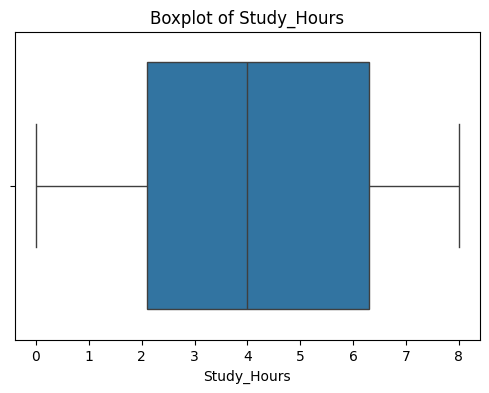

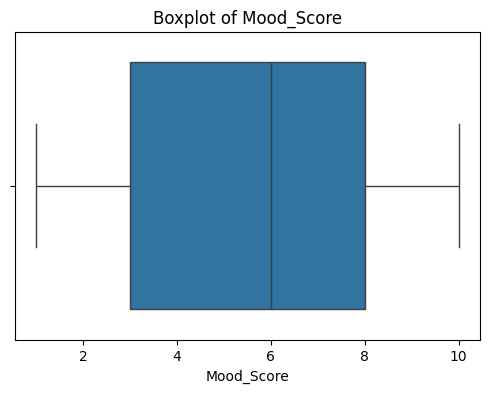

In [7]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


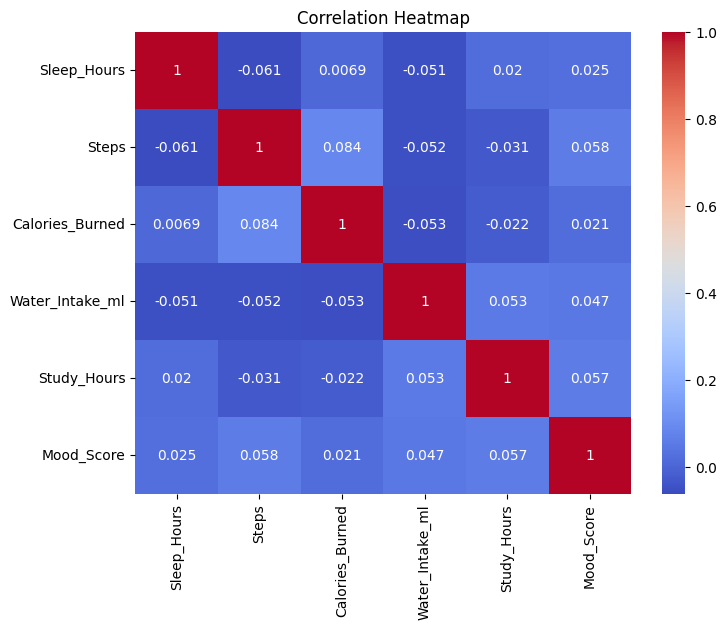

In [8]:
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [9]:
df.groupby("User_ID").mean(numeric_only=True)



,Sleep_Hours,Steps,Calories_Burned,Water_Intake_ml,Study_Hours,Mood_Score
User_ID,,,,,,
U001,5.8,19772.0,2645.0,571.0,0.4,2.0
U002,5.0,14764.0,3325.0,4890.0,4.1,6.0
U003,5.7,2225.0,1954.0,3183.0,4.6,1.0
U004,9.4,4055.0,2144.0,2530.0,3.3,4.0
U005,5.3,4314.0,2729.0,4028.0,2.5,8.0
...,...,...,...,...,...,...
U496,8.3,3858.0,2554.0,1360.0,6.8,2.0
U497,8.1,11675.0,2585.0,4495.0,6.6,8.0
U498,8.2,6493.0,3384.0,2924.0,1.3,6.0


DATA PREPROCESSING


In [10]:
df.columns


Index(['User_ID', 'Date', 'Wake_Up_Time', 'Sleep_Hours', 'Steps',
       'Calories_Burned', 'Water_Intake_ml', 'Study_Hours', 'Mood_Score'],
      dtype='object')

In [11]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   User_ID          500 non-null    object 
 1   Date             500 non-null    object 
 2   Wake_Up_Time     500 non-null    object 
 3   Sleep_Hours      500 non-null    float64
 4   Steps            500 non-null    int64  
 5   Calories_Burned  500 non-null    int64  
 6   Water_Intake_ml  500 non-null    int64  
 7   Study_Hours      500 non-null    float64
 8   Mood_Score       500 non-null    int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 35.3+ KB


,0
User_ID,0
Date,0
Wake_Up_Time,0
Sleep_Hours,0
Steps,0
Calories_Burned,0
Water_Intake_ml,0
Study_Hours,0
Mood_Score,0


In [12]:
df["Sleep_Hours"].fillna(df["Sleep_Hours"].median(), inplace=True)


/tmp/ipykernel_664/3620286179.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Sleep_Hours"].fillna(df["Sleep_Hours"].median(), inplace=True)


In [13]:
df["Mood_Score"].fillna(df["Mood_Score"].mode()[0], inplace=True)


/tmp/ipykernel_664/532515756.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Mood_Score"].fillna(df["Mood_Score"].mode()[0], inplace=True)


In [14]:
df.duplicated().sum()


np.int64(0)

In [15]:
df = df.drop_duplicates()


In [16]:
df.select_dtypes(include="object").columns


Index(['User_ID', 'Date', 'Wake_Up_Time'], dtype='object')

In [17]:
df = df.drop("User_ID", axis=1)


Feature engineering(Create New Features (Feature Construction))

In [18]:
df["Study_Sleep_Ratio"] = df["Study_Hours"] / (df["Sleep_Hours"] + 0.1)


In [19]:
df["Health_Index"] = df["Steps"] + (df["Water_Intake_ml"] / 100)


In [20]:
df["Calorie_per_Step"] = df["Calories_Burned"] / (df["Steps"] + 1)


In [21]:
df["Wake_Up_Time"] = pd.to_datetime(df["Wake_Up_Time"], format="%H:%M")



In [22]:
df["Wake_Hour"] = df["Wake_Up_Time"].dt.hour
df["Wake_Minute"] = df["Wake_Up_Time"].dt.minute


In [23]:
df["Date"] = pd.to_datetime(df["Date"])
df["Day"] = df["Date"].dt.day
df["Month"] = df["Date"].dt.month
df["Weekday"] = df["Date"].dt.weekday

df["Wake_Up_Time"] = pd.to_datetime(df["Wake_Up_Time"])
df["Wake_Hour"] = df["Wake_Up_Time"].dt.hour


In [24]:
df = df.drop(["Date", "Wake_Up_Time"], axis=1)


In [25]:
df.columns


Index(['Sleep_Hours', 'Steps', 'Calories_Burned', 'Water_Intake_ml',
       'Study_Hours', 'Mood_Score', 'Study_Sleep_Ratio', 'Health_Index',
       'Calorie_per_Step', 'Wake_Hour', 'Wake_Minute', 'Day', 'Month',
       'Weekday'],
      dtype='object')

Normalize Features



In [26]:
from sklearn.preprocessing import MinMaxScaler

features_to_scale = ["Study_Hours", "Sleep_Hours", "Steps", "Water_Intake_ml"]

scaler = MinMaxScaler()
df_scaled = df.copy()

df_scaled[features_to_scale] = scaler.fit_transform(df[features_to_scale])


Create Productivity Formula

In [27]:
df_scaled["Productivity_Score"] = (
    0.4 * df_scaled["Study_Hours"] +
    0.25 * df_scaled["Sleep_Hours"] +
    0.2 * df_scaled["Steps"] +
    0.15 * df_scaled["Water_Intake_ml"]
)


add noise

In [43]:
import numpy as np

np.random.seed(42)

df["Productivity_Score"] = df["Productivity_Score"] + np.random.normal(
    0, 0.3, len(df)
)

seperate target and variable

In [44]:
X = df.drop("Productivity_Score", axis=1)
y = df["Productivity_Score"]

In [45]:
df["Productivity_Score"] = (
    0.3 * df["Study_Hours"] +
    0.2 * df["Sleep_Hours"] +
    0.2 * df["Mood_Score"] +
    0.2 * df["Health_Index"] +
    0.1 * df["Wake_Hour"]
)


In [31]:
X = df.drop("Productivity_Score", axis=1)
y = df["Productivity_Score"]


In [46]:
import pandas as pd

# Correlation with target
corr_matrix = df.corr()

target_corr = corr_matrix["Productivity_Score"].abs()

# Keep features with correlation > 0.05
selected_features = target_corr[target_corr > 0.05].index

df = df[selected_features]

print("Selected Features:", selected_features)

Selected Features: Index(['Sleep_Hours', 'Steps', 'Calories_Burned', 'Water_Intake_ml',
       'Mood_Score', 'Health_Index', 'Calorie_per_Step', 'Wake_Hour',
       'Wake_Minute', 'Day', 'Weekday', 'Productivity_Score'],
      dtype='object')


Correlation with Target (Filter Method)

In [32]:
import numpy as np

corr_matrix = df.corr(numeric_only=True)

target_corr = corr_matrix["Productivity_Score"].sort_values(ascending=False)

print(target_corr)


Productivity_Score    1.000000
Health_Index          1.000000
Steps                 0.999997
Calories_Burned       0.084140
Mood_Score            0.058526
Wake_Hour             0.057749
Month                 0.037993
Study_Sleep_Ratio    -0.008572
Study_Hours          -0.030262
Water_Intake_ml      -0.050169
Day                  -0.057501
Sleep_Hours          -0.060849
Wake_Minute          -0.061939
Weekday              -0.069858
Calorie_per_Step     -0.651701
Name: Productivity_Score, dtype: float64


Remove Multicollinearity

In [33]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

X = X.drop(columns=to_drop)

print("Dropped due to multicollinearity:", to_drop)


Dropped due to multicollinearity: ['Study_Sleep_Ratio', 'Health_Index']


SEPERATING FEATURE AND TARGET VARIABLE

In [34]:
# X = features (all columns except target)
X = df.drop("Productivity_Score", axis=1)

# y = target variable
y = df["Productivity_Score"]

TRAIN TEST SPLIT


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

SCALING

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

model = LinearRegression()

cv_scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross Validation R2 Scores:", cv_scores)
print("Average CV R2:", cv_scores.mean())

Cross Validation R2 Scores: [1. 1. 1. 1. 1.]
Average CV R2: 1.0


MODEL 1: LINEAR REGRESSION

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression Results")
print("R2 Score:", r2_score(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("-" * 40)

Linear Regression Results
R2 Score: 1.0
RMSE: 1.693287594060029e-12
----------------------------------------


MODEL 2: Random Forest Regressor

In [38]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("-" * 40)

Random Forest Results
R2 Score: 0.9999034025541431
RMSE: 11.499463466335298
----------------------------------------


Gradient Boosting Regressor

In [39]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Results")
print("R2 Score:", r2_score(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("-" * 40)

Gradient Boosting Results
R2 Score: 0.9999074256368252
RMSE: 11.257452489310523
----------------------------------------


COMPARE ALL MODELS

In [40]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb))
    ]
})

print(results)

               Model  R2 Score          RMSE
0  Linear Regression  1.000000  1.693288e-12
1      Random Forest  0.999903  1.149946e+01
2  Gradient Boosting  0.999907  1.125745e+01


<Axes: >

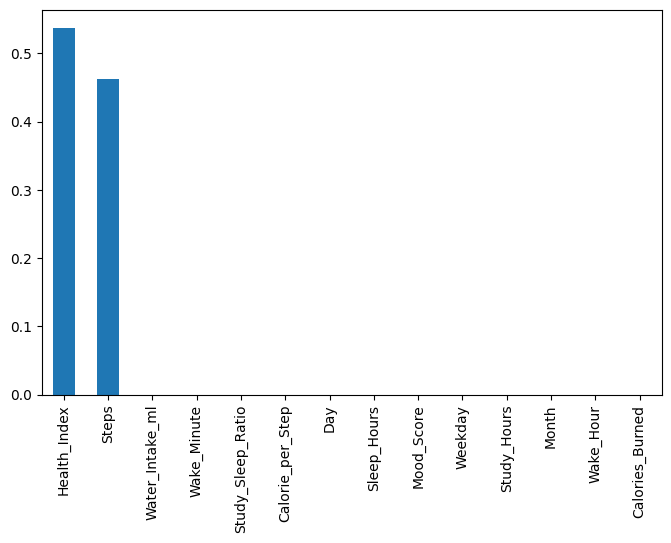

In [41]:
# Feature importance (Random Forest)

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind='bar', figsize=(8,5))

HYPERPARAMETER TUNING(RF)

In [47]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score: 0.9998527163794169


Train Final Optimized Model

In [48]:
best_model = grid.best_estimator_

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

Final Evaluation

In [49]:
from sklearn.metrics import r2_score, mean_squared_error

print("Test R2:", r2_score(y_test, y_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Test R2: 0.9999056375422588
Test RMSE: 11.365652619297313


Residual Analysis

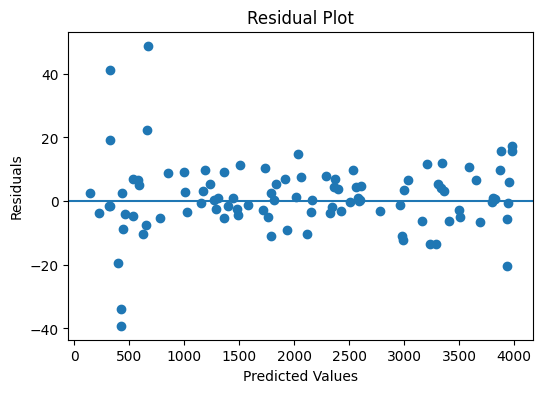

In [50]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()